# ARMA models: identification, selection and forecasting

An ARMA($p$, $q$) process combines an autoregressive part and a moving average part:

$$X_t = \phi_1 X_{t-1} + \dots + \phi_p X_{t-p} + W_t + \theta_1 W_{t-1} + \dots + \theta_q W_{t-q} .$$

Building an ARMA model follows a standard cycle:

1. **identify** plausible orders from the ACF and PACF;
2. **fit** the candidates and compare them with an information criterion (AIC, BIC) and the significance of the coefficients;
3. **check** that the residuals behave like white noise;
4. **evaluate** the forecasts on data the model has not seen, against simple baselines.

This notebook trains the identification step on simulated processes, then runs the full cycle on two real series: a series of unknown origin and the yearly area of sunspots.

In [1]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

## 1. What the ACF and PACF tell us

The theory gives a simple rule of thumb:

| Process | ACF | PACF |
|---|---|---|
| AR($p$) | decays gradually | cuts off after lag $p$ |
| MA($q$) | cuts off after lag $q$ | decays gradually |
| ARMA($p$, $q$) | decays gradually | decays gradually |

We check it on three processes driven by standard normal noise:

- **AR(2)**: $X_t = 0.9 X_{t-1} - 0.5 X_{t-2} + W_t$
- **MA(3)**: $X_t = W_t + 0.8 W_{t-1} - 0.5 W_{t-2} - 0.4 W_{t-3}$
- **ARMA(1,2)**: $X_t = -0.75 X_{t-1} + W_t - W_{t-1} + 0.25 W_{t-2}$

In `statsmodels` both polynomials include the leading 1, and the AR coefficients enter with the opposite sign: $\Phi(z) = 1 - \phi_1 z - \dots$

AR(2): stationary = True, invertible = True
MA(3): stationary = True, invertible = True
ARMA(1,2): stationary = True, invertible = True


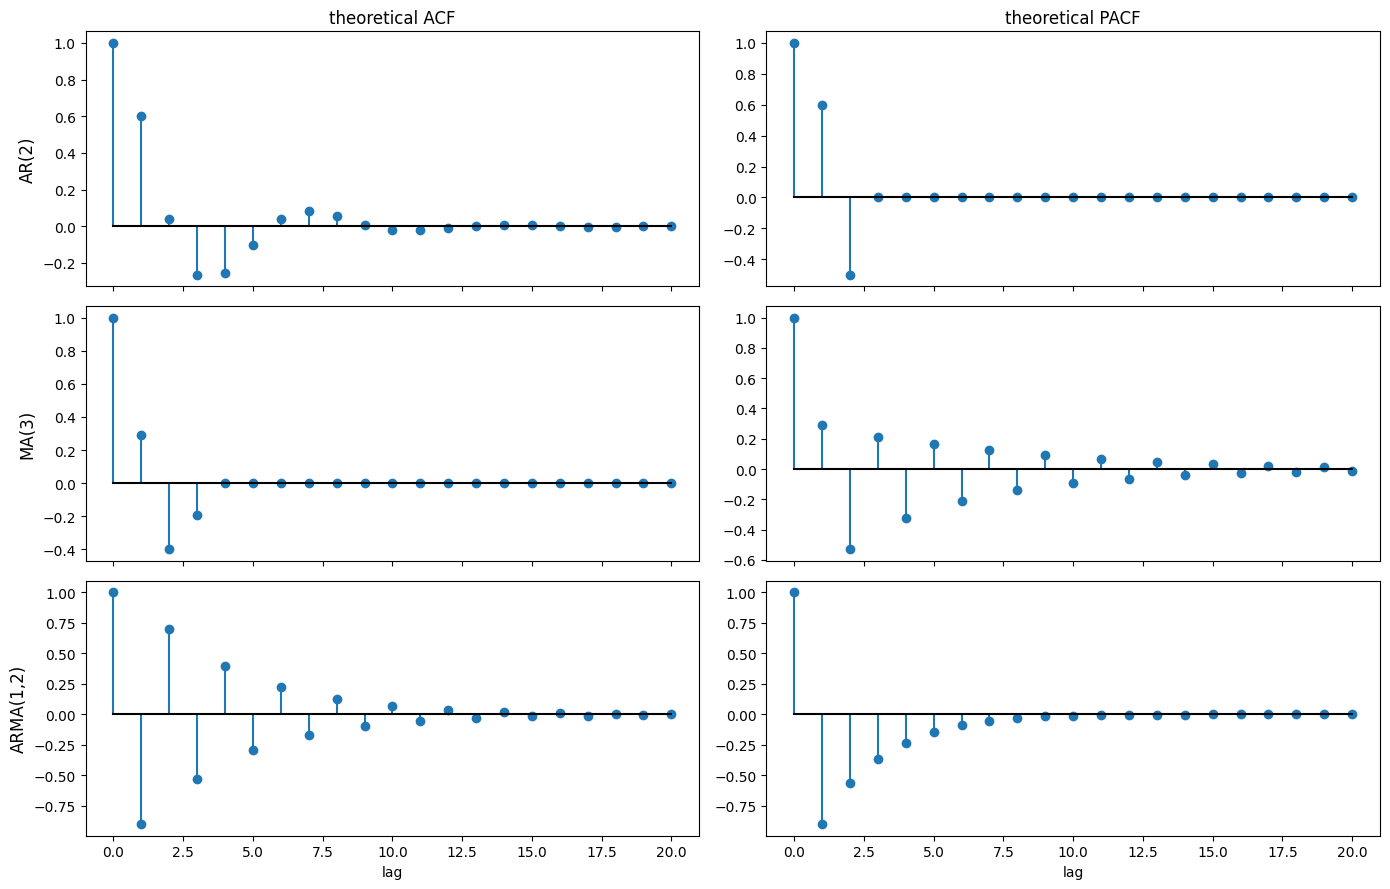

In [2]:
processes = {
    "AR(2)": ArmaProcess(ar=[1, -0.9, 0.5], ma=[1]),
    "MA(3)": ArmaProcess(ar=[1], ma=[1, 0.8, -0.5, -0.4]),
    "ARMA(1,2)": ArmaProcess(ar=[1, 0.75], ma=[1, -1, 0.25]),
}
lags = 20
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
for row, (name, proc) in enumerate(processes.items()):
    axes[row, 0].stem(range(lags + 1), proc.acf(lags + 1), basefmt="black")
    axes[row, 1].stem(range(lags + 1), proc.pacf(lags + 1), basefmt="black")
    axes[row, 0].set_ylabel(name, fontsize=12)
    print(f"{name}: stationary = {proc.isstationary}, invertible = {proc.isinvertible}")
axes[0, 0].set_title("theoretical ACF")
axes[0, 1].set_title("theoretical PACF")
axes[2, 0].set_xlabel("lag")
axes[2, 1].set_xlabel("lag")
fig.tight_layout()
plt.show()

The theoretical patterns follow the table:

- **AR(2)**: the ACF is a damped wave, the PACF has exactly two non-zero values (the second equals $\phi_2 = -0.5$).
- **MA(3)**: the ACF is non-zero only up to lag 3, while the PACF decays.
- **ARMA(1,2)**: both decay with alternating signs (caused by the negative AR coefficient), so neither shows a clean cut-off. Mixed models are the hardest to identify by eye.

In practice we only see **sample** estimates. How clearly do the patterns show up in a realistic amount of data?

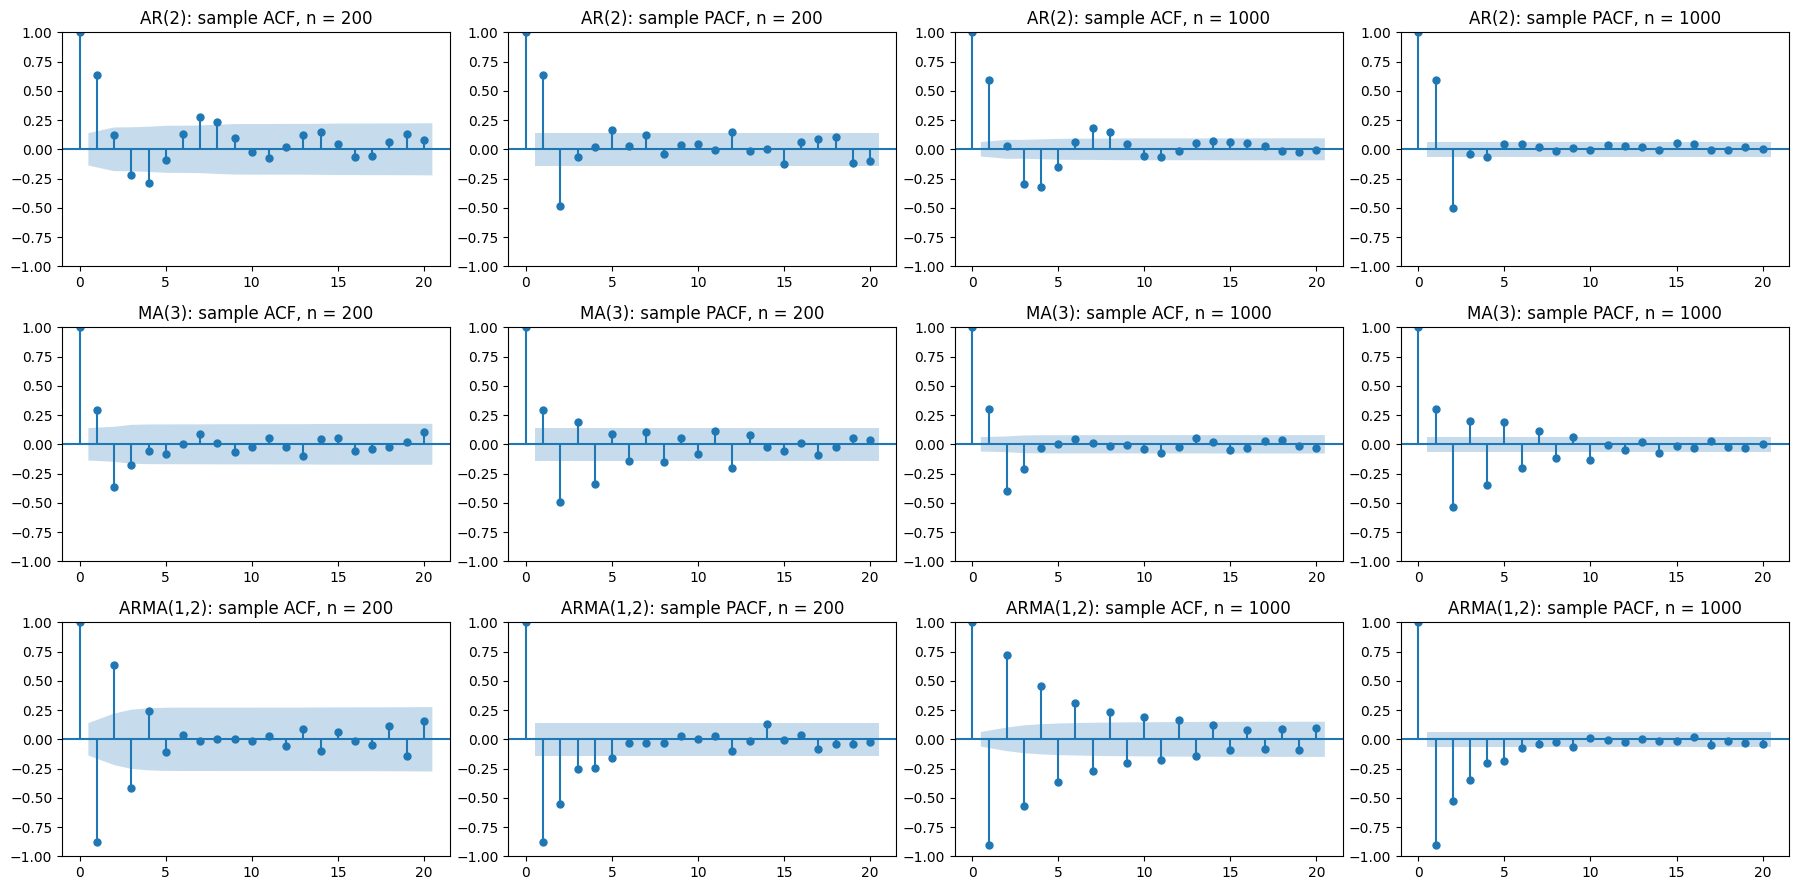

In [3]:
np.random.seed(0)
fig, axes = plt.subplots(3, 4, figsize=(18, 9))
for row, (name, proc) in enumerate(processes.items()):
    for col, n in enumerate([200, 1000]):
        sample = proc.generate_sample(nsample=n)
        plot_acf(sample, lags=lags, ax=axes[row, 2 * col], title=f"{name}: sample ACF, n = {n}")
        plot_pacf(sample, lags=lags, ax=axes[row, 2 * col + 1], title=f"{name}: sample PACF, n = {n}", method="ywm")
fig.tight_layout()
plt.show()

With 200 observations the main features are visible, but noise makes the picture ambiguous: some lags beyond the theoretical cut-off cross the 95% band, and small true values may not. With 1,000 observations the estimates are much closer to the theory. **ACF and PACF suggest candidates; they do not decide the model.** That is the job of the next steps.

## 2. Selecting a model for an unknown series

We now have 200 observations of a series whose generating process is unknown.

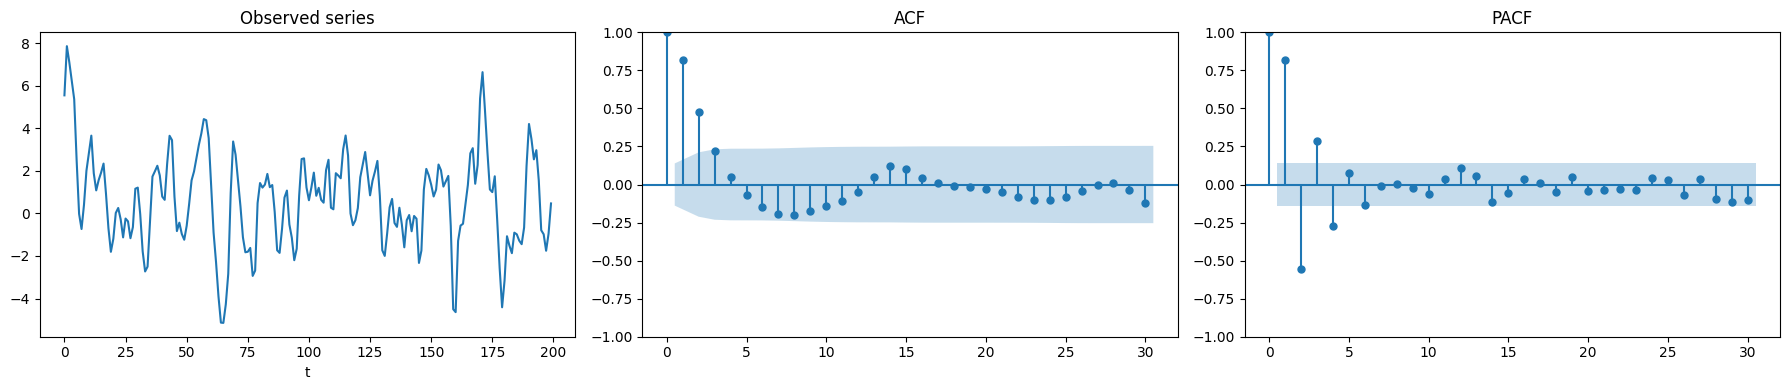

In [4]:
series = pd.read_csv("data/arma_sample.csv")["x"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
series.plot(ax=axes[0], title="Observed series", xlabel="t")
plot_acf(series, lags=30, ax=axes[1], title="ACF")
plot_pacf(series, lags=30, ax=axes[2], title="PACF", method="ywm")
fig.tight_layout()
plt.show()

The series fluctuates around a constant level with no trend, so we treat it as stationary. The ACF oscillates and decays; the PACF has significant values up to lag 4 and then fades. Plausible starting points are an **AR(4)** (PACF cut-off), an **MA(3)** (the ACF becomes small after lag 3) and low-order **ARMA** models.

Rather than testing models one at a time, we fit all ARMA($p$, $q$) with $p, q \le 5$ and compare AIC and BIC. BIC penalizes extra parameters more strongly and favours simpler models.

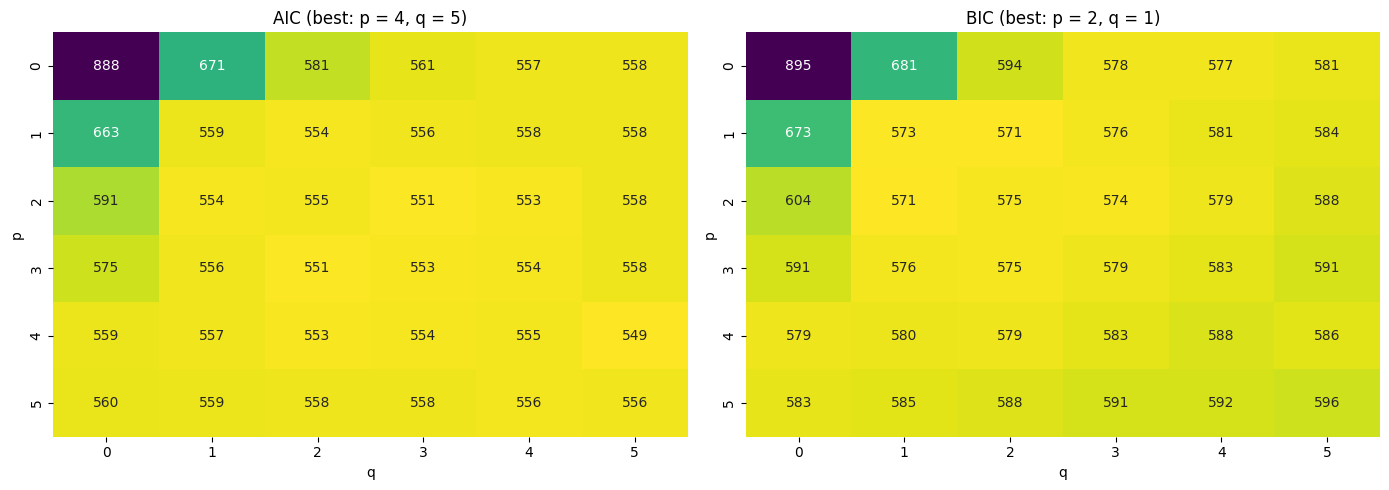

,p,q,AIC,BIC
13,2,1,554.0,570.5
8,1,2,554.1,570.6
7,1,1,559.4,572.6
15,2,3,550.9,573.9
20,3,2,551.5,574.6


In [5]:
scores = []
for p, q in itertools.product(range(6), range(6)):
    fit = ARIMA(series, order=(p, 0, q)).fit()
    scores.append({"p": p, "q": q, "AIC": fit.aic, "BIC": fit.bic})
scores = pd.DataFrame(scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, crit in zip(axes, ["AIC", "BIC"]):
    table = scores.pivot(index="p", columns="q", values=crit)
    sns.heatmap(table, annot=True, fmt=".0f", cmap="viridis_r", ax=ax, cbar=False)
    best = scores.loc[scores[crit].idxmin()]
    ax.set_title(f"{crit} (best: p = {int(best['p'])}, q = {int(best['q'])})")
fig.tight_layout()
plt.show()
scores.sort_values("BIC").head(5).round(1)

AIC is lowest for a large ARMA(4,5), but the differences between many models are small: AIC keeps rewarding extra parameters that capture noise. BIC points to compact models, and **ARMA(2,1)** combines a low BIC with only three coefficients. We compare it with the two pure models suggested by the plots.

To check whether the residuals are white noise we use the **Ljung-Box test**, which tests jointly whether the first $h$ autocorrelations of the residuals are all zero. A small p-value means dependence is left in the residuals.

In [6]:
candidates = {"AR(4)": (4, 0, 0), "MA(3)": (0, 0, 3), "ARMA(2,1)": (2, 0, 1)}
fits = {name: ARIMA(series, order=order).fit() for name, order in candidates.items()}
pd.DataFrame({
    name: {
        "parameters": len(fit.params) - 1,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "largest coefficient p-value": fit.pvalues.drop(["const", "sigma2"]).max(),
        "Ljung-Box p-value (lag 10)": acorr_ljungbox(fit.resid, lags=[10])["lb_pvalue"].iloc[0],
        "Ljung-Box p-value (lag 20)": acorr_ljungbox(fit.resid, lags=[20])["lb_pvalue"].iloc[0],
    }
    for name, fit in fits.items()
}).T.round(3)

,parameters,AIC,BIC,largest coefficient p-value,Ljung-Box p-value (lag 10),Ljung-Box p-value (lag 20)
AR(4),5.0,559.331,579.121,0.000,0.723,0.594
MA(3),4.0,561.288,577.780,0.000,0.245,0.427
"ARMA(2,1)",4.0,554.022,570.513,0.008,0.970,0.837


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6420      0.315      2.036      0.042       0.024       1.260
ar.L1          0.8915      0.098      9.100      0.000       0.699       1.084
ar.L2         -0.2411      0.090     -2.668      0.008      -0.418      -0.064
ma.L1          0.7061      0.077      9.171      0.000       0.555       0.857
sigma2         0.8772      0.096      9.154      0.000       0.689       1.065


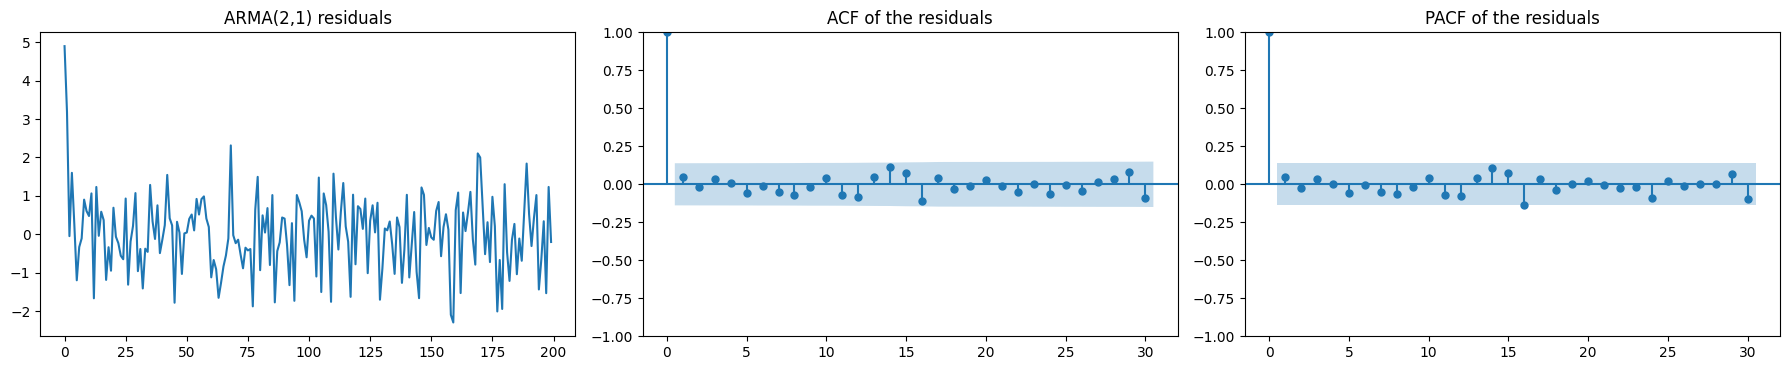

In [7]:
best = fits["ARMA(2,1)"]
print(best.summary().tables[1])
fig, axes = plt.subplots(1, 3, figsize=(18, 3.8))
best.resid.plot(ax=axes[0], title="ARMA(2,1) residuals")
plot_acf(best.resid, lags=30, ax=axes[1], title="ACF of the residuals")
plot_pacf(best.resid, lags=30, ax=axes[2], title="PACF of the residuals", method="ywm")
fig.tight_layout()
plt.show()

All three candidates leave residuals that pass the Ljung-Box test, but **ARMA(2,1)** does so with fewer parameters than the AR(4), all its coefficients are significant, and it has a clearly lower AIC and BIC than both pure models. Its residuals look like white noise; an isolated spike far out at lag 16 is the kind of value expected by chance among 30 lags.

This is the general lesson: a mixed model can describe with three parameters what a pure AR or MA model needs more terms for.

## 3. Forecasting sunspots

Sunspots are dark regions on the Sun's surface caused by magnetic activity. The dataset gives the monthly average area covered by sunspots (in millionths of the visible hemisphere) since 1874. We work with yearly averages from 1875 to 2015.

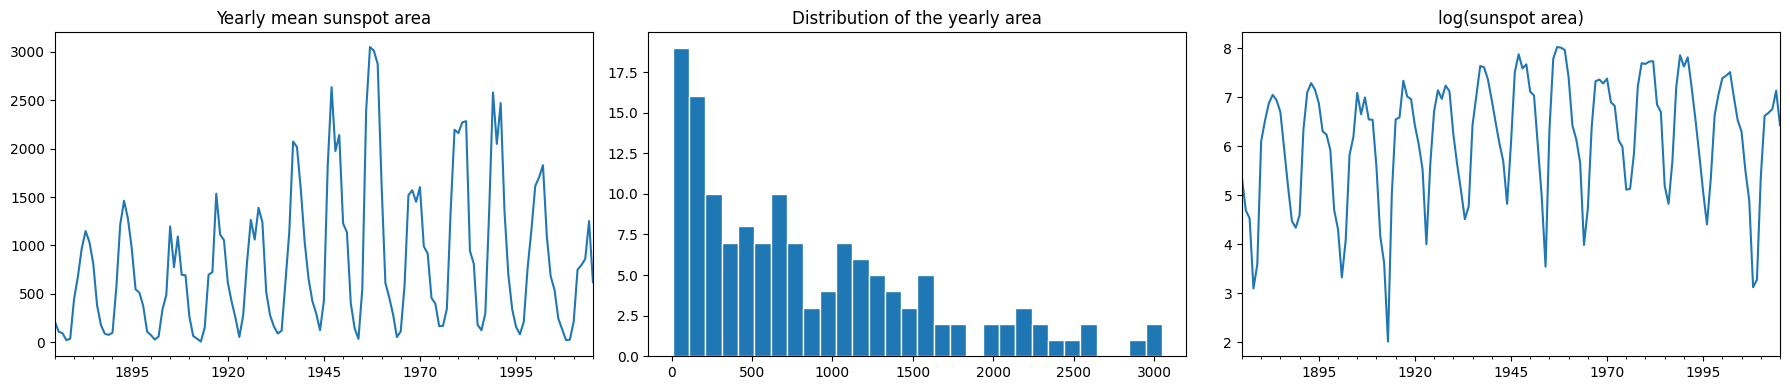

In [8]:
spots = pd.read_csv("data/sunspot_area_monthly.csv")
spots.index = pd.to_datetime(spots[["year", "month"]].assign(day=1))
area = spots["area"].resample("YS").mean()["1875":"2015"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
area.plot(ax=axes[0], title="Yearly mean sunspot area")
axes[1].hist(area, bins=30, edgecolor="white")
axes[1].set_title("Distribution of the yearly area")
np.log(area).plot(ax=axes[2], title="log(sunspot area)")
fig.tight_layout()
plt.show()

The series follows the well-known **11-year solar cycle**. The raw values are strongly right-skewed and the peaks vary much more than the troughs, so we model the logarithm, which has a more symmetric distribution and a more stable variance.

We fit models on the first 100 years (1875–1974) and keep 1975–2015 (41 years, almost four solar cycles) to evaluate the forecasts.

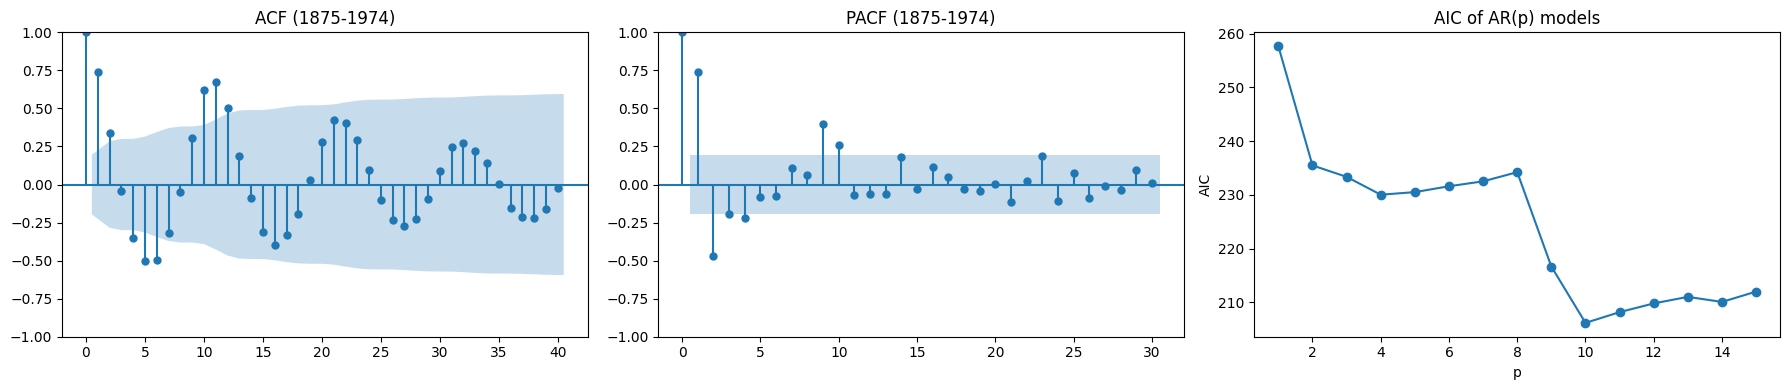

AR order with the lowest AIC: 10


In [9]:
log_area = np.log(area)
train, test = log_area[:"1974"], log_area["1975":]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
plot_acf(train, lags=40, ax=axes[0], title="ACF (1875-1974)")
plot_pacf(train, lags=30, ax=axes[1], title="PACF (1875-1974)", method="ywm")
aic = {p: ARIMA(train, order=(p, 0, 0)).fit().aic for p in range(1, 16)}
axes[2].plot(list(aic), list(aic.values()), "o-")
axes[2].set(title="AIC of AR(p) models", xlabel="p", ylabel="AIC")
fig.tight_layout()
plt.show()
print("AR order with the lowest AIC:", min(aic, key=aic.get))

The ACF oscillates with a period of about 11 years, as expected. The PACF has strong values at lags 1–2 and further significant spikes around lags 9–10, which reflect the length of the cycle. AIC confirms this: it drops sharply at $p = 9$ and $p = 10$ and is lowest for **AR(10)**. We compare AR(2), AR(9) and AR(10).

In [10]:
ar_models = {p: ARIMA(train, order=(p, 0, 0)).fit() for p in (2, 9, 10)}
pd.DataFrame({
    f"AR({p})": {"AIC": m.aic, "Ljung-Box p-value (lag 15)": acorr_ljungbox(m.resid, lags=[15])["lb_pvalue"].iloc[0]}
    for p, m in ar_models.items()
}).T.round(3)

,AIC,Ljung-Box p-value (lag 15)
AR(2),235.491,0.001
AR(9),216.681,0.405
AR(10),206.203,0.907


The AR(2) leaves significant dependence in its residuals (Ljung-Box p ≈ 0.001): two lags cannot reproduce an 11-year cycle. AR(9) and AR(10) both pass the test, and AR(10) has the lower AIC.

### Out-of-sample evaluation

We forecast all 41 years from 1975 at once and compare with what actually happened. As benchmarks we use two simple forecasts that require no model:

- the **mean** of the training years;
- a **"seasonal naive"** forecast that simply repeats the last observed 11-year cycle.

In [11]:
forecasts = {}
for p, m in ar_models.items():
    fc = m.get_forecast(len(test)).summary_frame()
    fc.index = test.index
    forecasts[f"AR({p})"] = fc

last_cycle = train.values[-11:]
baselines = {
    "training mean": pd.Series(train.mean(), index=test.index),
    "repeat last 11-year cycle": pd.Series(np.resize(last_cycle, len(test)), index=test.index),
}

def errors(pred):
    e = test - pred
    return {"RMSE": np.sqrt(np.mean(e ** 2)), "MAE": np.mean(np.abs(e))}

table = {name: errors(fc["mean"]) for name, fc in forecasts.items()}
table.update({name: errors(pred) for name, pred in baselines.items()})
pd.DataFrame(table).T.round(3).sort_values("RMSE")

,RMSE,MAE
repeat last 11-year cycle,0.781,0.655
AR(10),0.830,0.633
AR(9),0.998,0.836
AR(2),1.218,1.052
training mean,1.225,1.061


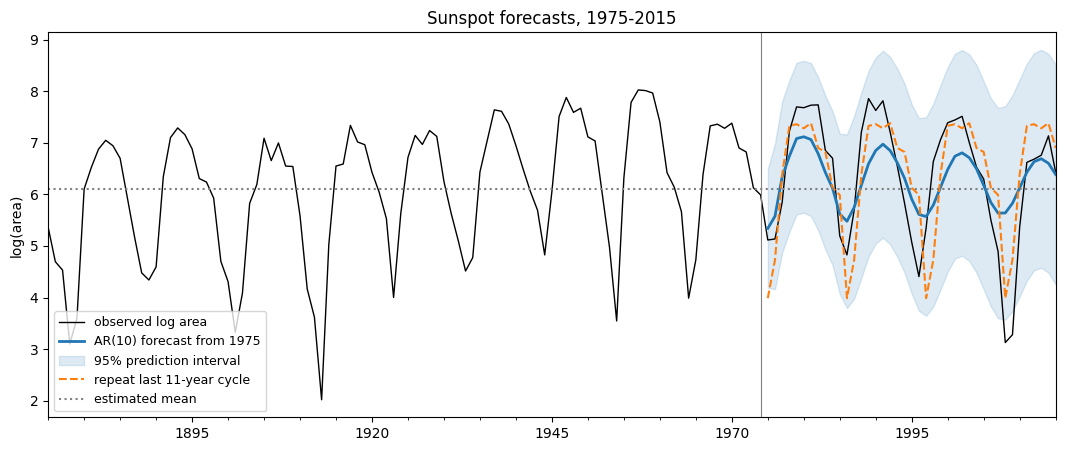

In [12]:
fc = forecasts["AR(10)"]
fig, ax = plt.subplots(figsize=(13, 5))
log_area.plot(ax=ax, color="black", lw=1, label="observed log area")
fc["mean"].plot(ax=ax, color="tab:blue", lw=2, label="AR(10) forecast from 1975")
ax.fill_between(fc.index, fc["mean_ci_lower"], fc["mean_ci_upper"], color="tab:blue", alpha=0.15, label="95% prediction interval")
baselines["repeat last 11-year cycle"].plot(ax=ax, color="tab:orange", ls="--", label="repeat last 11-year cycle")
ax.axhline(ar_models[10].params["const"], color="grey", ls=":", label="estimated mean")
ax.axvline(pd.Timestamp("1974-07-01"), color="grey", lw=0.8)
ax.set(title="Sunspot forecasts, 1975-2015", ylabel="log(area)", xlabel="")
ax.legend(loc="lower left", fontsize=9)
plt.show()

The AR(10) forecast captures the timing of the next solar cycles remarkably well. As the horizon grows, though, its oscillation is damped and the forecast drifts towards the mean, so it increasingly underestimates the peaks and overestimates the troughs. This happens to every stationary model. Most observations stay inside the 95% prediction interval.

The AR(10) reduces the error of the mean forecast by about a third. However, the naive forecast that just repeats the last cycle is **just as good**: it has a slightly lower RMSE and a slightly higher MAE than the AR(10). The solar cycle is so regular that copying it is hard to beat: the naive forecast keeps the full amplitude of the cycle, which the AR model slowly loses through damping, but it also repeats the last cycle's exact shape, so it pays more when the timing drifts. A model that represents the cycle explicitly, for example with a seasonal component of period 11, would combine the two strengths.

**Takeaway:** always compare a model against simple, domain-informed baselines. A model with good diagnostics and a low AIC can still be matched by common sense.

## Summary

- **ACF/PACF** patterns (cut-off vs gradual decay) suggest which AR, MA or ARMA orders to try, but sample noise makes them ambiguous for short series.
- **AIC** tends to favour large models; **BIC** and the significance of coefficients help keep the model simple.
- The **Ljung-Box test** checks whether residuals are white noise; a model that leaves dependence behind is missing structure.
- A **mixed ARMA** model can be more parsimonious than a pure AR or MA model.
- Forecasts must be evaluated **out of sample** and against **baselines**. For strongly periodic series a seasonal naive forecast is a demanding benchmark.